# EP17 — Graph Neural Networks (GCN)
**COMPSCI 713 · S1 2025 Q8 · 3 marks**

Explain the role of each element in the GCN update equation:

$$h_{k+1}^{(n)} = \mathbf{a}\left[\beta_k + \Omega_k h_k^{(n)} + \Omega_k \mathbf{agg}[n]\right]$$

- **β_k and Ω_k** — 1 mark
- **agg[n]** — 1 mark  
- **a[·]** — 1 mark

---

## GCN Update Equation — Full Explanation

### Overview
A Graph Convolutional Network (GCN) updates each node's hidden representation by combining:
1. Its **own** current representation
2. The **aggregated** representations of its neighbours
3. A learned **bias**
4. A **non-linear activation** to introduce expressiveness

---

### β_k and Ω_k — Learnable Parameters [1 mark]

- **β_k** is the **bias vector** at layer k. It shifts the activation, allowing the model to represent functions that don't pass through the origin. It is shared across all nodes at layer k.

- **Ω_k** is the **weight matrix** at layer k (shared across all nodes). It performs a linear transformation that:
  - Projects the node's own features into a new representation space: `Ω_k h_k^(n)` (self-transformation)
  - Projects the aggregated neighbour features into the same space: `Ω_k agg[n]` (neighbour transformation)
  - Using the **same Ω_k for both** means the model treats the node's own embedding and its neighbourhood signal in a consistent, shared feature space. This is a design choice for parameter efficiency.

*Note: some GCN variants use separate weight matrices for self vs neighbour — the shared version here is a simplified formulation.*

---

### agg[n] — Neighbourhood Aggregation [1 mark]

`agg[n]` is the **aggregated representation of node n's neighbours** at layer k. It summarises the structural information from the local graph neighbourhood.

Common aggregation functions:
- **Mean:** `agg[n] = (1/|N(n)|) Σ_{m ∈ N(n)} h_k^(m)` — averages neighbour embeddings
- **Sum:** `agg[n] = Σ_{m ∈ N(n)} h_k^(m)` — sums neighbour embeddings
- **Max:** element-wise maximum across neighbours

**What it accomplishes:** After L layers, a node's embedding encodes information from its L-hop neighbourhood. This is how GCNs capture graph structure — each node learns from the topology around it, not just its own features.

---

### a[·] — Activation Function [1 mark]

`a[·]` is a **non-linear activation function** (e.g., ReLU, tanh) applied element-wise to the linear combination.

**Why it's needed:**
- Without activation, stacking multiple GCN layers reduces to a single linear transformation (no expressive power gain)
- The activation introduces **non-linearity**, allowing the network to learn complex, non-linear functions of the graph structure
- It also controls the scale/range of the hidden representations between layers

---

## Full Picture

```
For each node n at layer k:

  h_{k+1}^(n)  =  a[ β_k  +  Ω_k · h_k^(n)  +  Ω_k · agg[n] ]
                        ↑            ↑                  ↑
                     bias       self-transform    neighbour-transform
                  (learnable)  (learnable Ω_k)   (same Ω_k applied
                                                  to agg of neighbours)
```

This is the **message passing** paradigm: nodes receive messages from neighbours, aggregate them, transform the result, and update their own representation.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)

# =============================================================
# Manual GCN forward pass — shows exactly what each term does
# =============================================================

# A small graph: 5 nodes, adjacency list
# 0-1, 0-2, 1-3, 2-3, 3-4
edges = [(0,1),(1,0), (0,2),(2,0), (1,3),(3,1), (2,3),(3,2), (3,4),(4,3)]
n_nodes = 5

# Build adjacency (excluding self-loops for clarity)
adj = {i: [] for i in range(n_nodes)}
for src, dst in edges:
    adj[src].append(dst)

# Initial node features: 2D (e.g., node type one-hot)
H = np.array([
    [1.0, 0.0],   # node 0
    [0.5, 0.5],   # node 1
    [0.0, 1.0],   # node 2
    [0.8, 0.2],   # node 3
    [0.3, 0.7],   # node 4
], dtype=float)

# Learnable parameters: Omega (2x2), beta (2,)
Omega = np.array([[0.5, -0.2], [0.1,  0.8]])
beta  = np.array([0.1, 0.0])

def relu(x): return np.maximum(0, x)

def gcn_layer(H, adj, Omega, beta):
    """One GCN layer: h_{k+1}^n = ReLU(beta + Omega*h_k^n + Omega*agg[n])"""
    H_new = np.zeros_like(H)
    details = {}
    for n in range(len(H)):
        # Self term
        self_term = Omega @ H[n]
        # Aggregation: mean of neighbours
        neighbours = adj[n]
        if neighbours:
            agg_n = np.mean(H[neighbours], axis=0)  # mean aggregation
        else:
            agg_n = np.zeros(H.shape[1])
        neighbour_term = Omega @ agg_n
        # Full update
        linear = beta + self_term + neighbour_term
        H_new[n] = relu(linear)
        details[n] = {
            'neighbours': neighbours,
            'agg_n': agg_n,
            'self_term': self_term,
            'neighbour_term': neighbour_term,
            'linear': linear,
            'activated': H_new[n]
        }
    return H_new, details

print('=== GCN Forward Pass ===')
print('Initial node features H_0:')
for i, h in enumerate(H):
    print(f'  Node {i}: {h}')
print()

H1, details = gcn_layer(H, adj, Omega, beta)

print('Layer 1 computation for each node:')
for n, d in details.items():
    print(f'\nNode {n} (neighbours: {d["neighbours"]}):')
    print(f'  agg[{n}]        = mean(h_neighbours) = {d["agg_n"].round(3)}')
    print(f'  Ω·h_k^({n})     = {d["self_term"].round(3)}')
    print(f'  Ω·agg[{n}]      = {d["neighbour_term"].round(3)}')
    print(f'  β + both terms = {d["linear"].round(3)}')
    print(f'  ReLU(...)      = h_1^({n}) = {d["activated"].round(3)}')

=== GCN Forward Pass ===
Initial node features H_0:
  Node 0: [1. 0.]
  Node 1: [0.5 0.5]
  Node 2: [0. 1.]
  Node 3: [0.8 0.2]
  Node 4: [0.3 0.7]

Layer 1 computation for each node:

Node 0 (neighbours: [1, 2]):
  agg[0]        = mean(h_neighbours) = [0.25 0.75]
  Ω·h_k^(0)     = [0.5 0.1]
  Ω·agg[0]      = [-0.025  0.625]
  β + both terms = [0.575 0.725]
  ReLU(...)      = h_1^(0) = [0.575 0.725]

Node 1 (neighbours: [0, 3]):
  agg[1]        = mean(h_neighbours) = [0.9 0.1]
  Ω·h_k^(1)     = [0.15 0.45]
  Ω·agg[1]      = [0.43 0.17]
  β + both terms = [0.68 0.62]
  ReLU(...)      = h_1^(1) = [0.68 0.62]

Node 2 (neighbours: [0, 3]):
  agg[2]        = mean(h_neighbours) = [0.9 0.1]
  Ω·h_k^(2)     = [-0.2  0.8]
  Ω·agg[2]      = [0.43 0.17]
  β + both terms = [0.33 0.97]
  ReLU(...)      = h_1^(2) = [0.33 0.97]

Node 3 (neighbours: [1, 2, 4]):
  agg[3]        = mean(h_neighbours) = [0.267 0.733]
  Ω·h_k^(3)     = [0.36 0.24]
  Ω·agg[3]      = [-0.013  0.613]
  β + both terms = [0.447

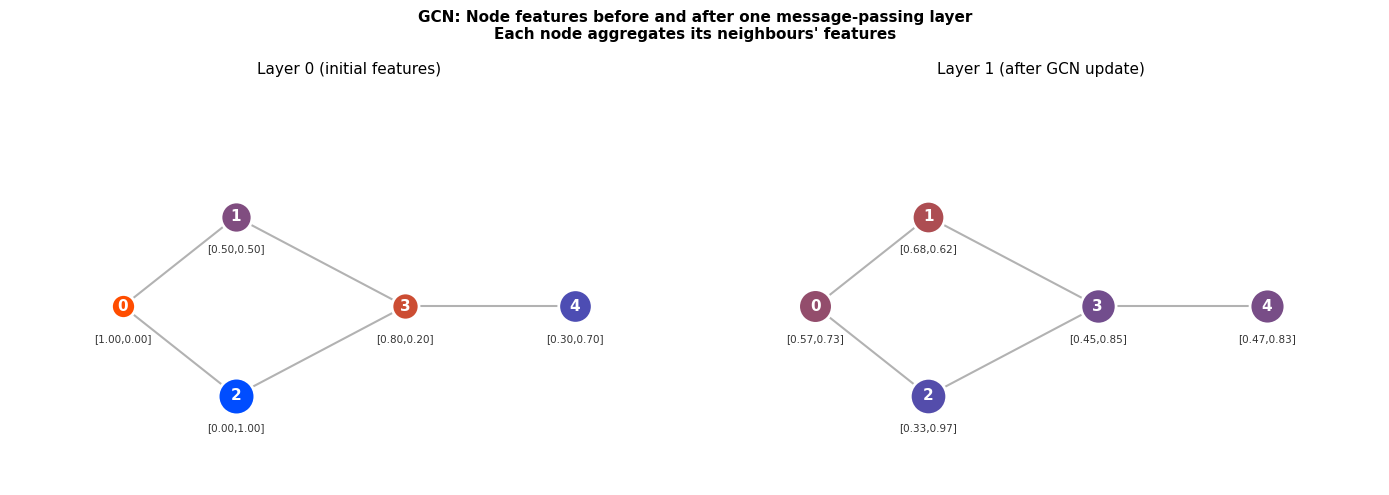

In [2]:
# =============================================================
# Visualisation 1: graph + node embedding evolution
# =============================================================
node_positions = {
    0: (1, 3), 1: (2, 4), 2: (2, 2),
    3: (3.5, 3), 4: (5, 3)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, H_data, title in [(axes[0], H, 'Layer 0 (initial features)'),
                           (axes[1], H1, 'Layer 1 (after GCN update)')]:
    # Draw edges
    drawn = set()
    for src, dst in edges:
        key = tuple(sorted([src, dst]))
        if key not in drawn:
            x0,y0 = node_positions[src]
            x1,y1 = node_positions[dst]
            ax.plot([x0,x1],[y0,y1], 'k-', alpha=0.3, zorder=1)
            drawn.add(key)

    # Draw nodes (colour = first feature dim, size = second)
    for n in range(n_nodes):
        x, y = node_positions[n]
        colour_val = H_data[n, 0]
        size_val   = 300 + H_data[n, 1] * 400
        sc = ax.scatter(x, y, s=size_val,
                        c=[[colour_val, 0.3, 1-colour_val]],
                        zorder=4, edgecolors='white', linewidths=2)
        ax.text(x, y, str(n), ha='center', va='center',
                fontsize=11, fontweight='bold', color='white', zorder=5)
        ax.text(x, y-0.4, f'[{H_data[n,0]:.2f},{H_data[n,1]:.2f}]',
                ha='center', fontsize=7.5, color='#333')

    ax.set_xlim(0, 6); ax.set_ylim(1, 5.5)
    ax.axis('off')
    ax.set_title(title, fontsize=11)

fig.suptitle('GCN: Node features before and after one message-passing layer\n'
             'Each node aggregates its neighbours\' features',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

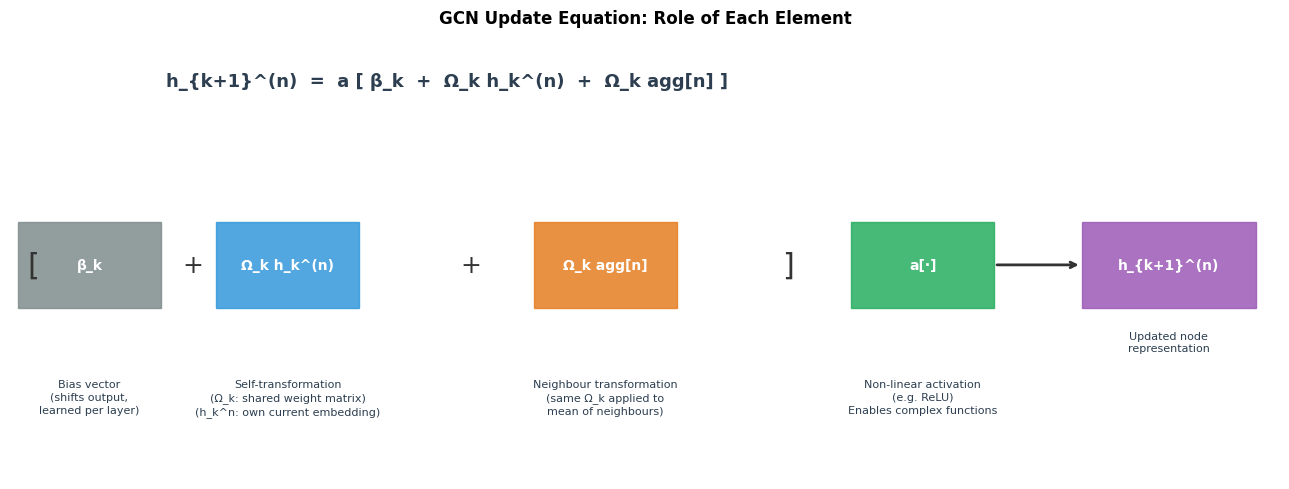

In [3]:
# =============================================================
# Visualisation 2: equation breakdown diagram
# =============================================================
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')
ax.set_xlim(0, 16); ax.set_ylim(0, 6)

# Main equation boxes
components = [
    (1.0, 3.0, 'β_k', '#7f8c8d',
     'Bias vector\n(shifts output,\nlearned per layer)'),
    (3.5, 3.0, 'Ω_k h_k^(n)', '#3498db',
     'Self-transformation\n(Ω_k: shared weight matrix)\n(h_k^n: own current embedding)'),
    (7.5, 3.0, 'Ω_k agg[n]', '#e67e22',
     'Neighbour transformation\n(same Ω_k applied to\nmean of neighbours)'),
    (11.5, 3.0, 'a[·]', '#27ae60',
     'Non-linear activation\n(e.g. ReLU)\nEnables complex functions'),
]

for x, y, label, colour, desc in components:
    ax.add_patch(plt.Rectangle((x-0.9, y-0.6), 1.8, 1.2,
                                color=colour, alpha=0.85, zorder=2))
    ax.text(x, y, label, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white', zorder=3)
    ax.text(x, y-1.6, desc, ha='center', va='top', fontsize=8,
            color='#2c3e50', zorder=3, linespacing=1.4)

# Plus signs and brackets
for xp in [2.3, 5.8]:
    ax.text(xp, 3.0, '+', ha='center', va='center', fontsize=18, color='#333')
ax.text(9.8, 3.0, ']', ha='center', va='center', fontsize=22, color='#333')
ax.text(0.3, 3.0, '[', ha='center', va='center', fontsize=22, color='#333')

# Output
ax.add_patch(plt.Rectangle((13.5, 2.4), 2.2, 1.2, color='#9b59b6', alpha=0.85, zorder=2))
ax.text(14.6, 3.0, 'h_{k+1}^(n)', ha='center', va='center', fontsize=10,
        fontweight='bold', color='white', zorder=3)
ax.text(14.6, 1.8, 'Updated node\nrepresentation', ha='center',
        fontsize=8, color='#2c3e50')

ax.annotate('', xy=(13.5, 3.0), xytext=(12.4, 3.0),
            arrowprops=dict(arrowstyle='->', color='#333', lw=2))
ax.text(5.5, 5.5, 'h_{k+1}^(n)  =  a [ β_k  +  Ω_k h_k^(n)  +  Ω_k agg[n] ]',
        ha='center', fontsize=13, fontweight='bold', color='#2c3e50')

ax.set_title('GCN Update Equation: Role of Each Element', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

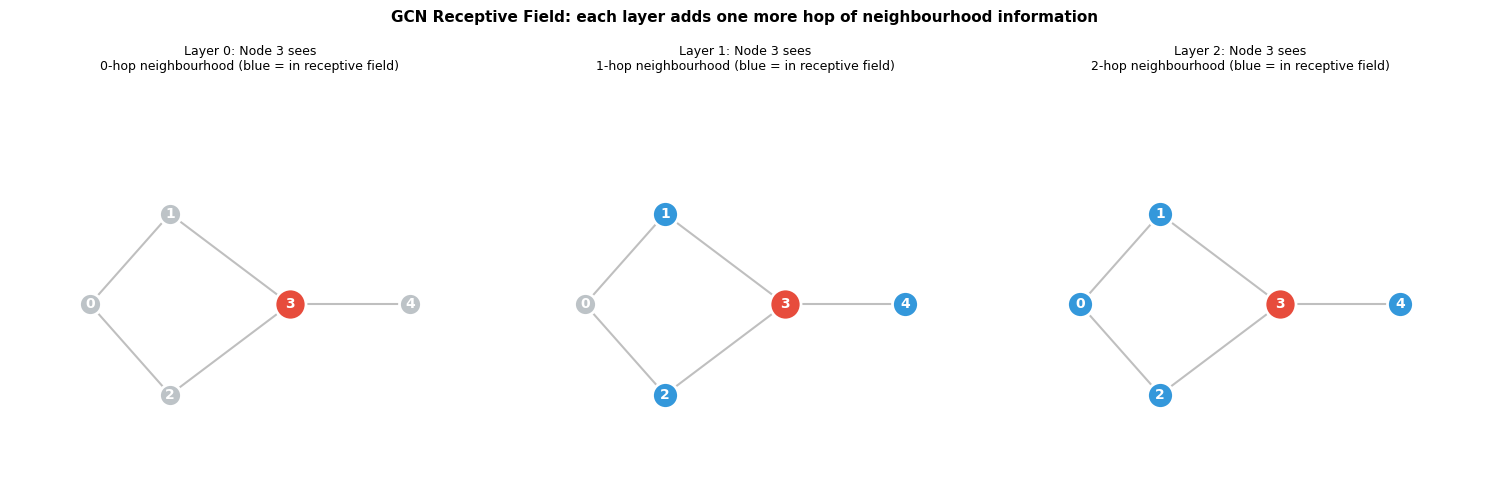

In [4]:
# =============================================================
# Visualisation 3: multi-layer receptive field
# Shows how many hops of info reach a node at each layer
# =============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for layer_idx, ax in enumerate(axes):
    drawn = set()
    for src, dst in edges:
        key = tuple(sorted([src, dst]))
        if key not in drawn:
            x0,y0 = node_positions[src]
            x1,y1 = node_positions[dst]
            ax.plot([x0,x1],[y0,y1], 'k-', alpha=0.25, zorder=1)
            drawn.add(key)

    # BFS: which nodes are within `layer_idx` hops of node 3?
    focus = 3
    reachable = {focus}
    frontier  = {focus}
    for _ in range(layer_idx):
        next_f = set()
        for node in frontier:
            next_f.update(adj[node])
        frontier  = next_f - reachable
        reachable.update(frontier)

    for n in range(n_nodes):
        x, y = node_positions[n]
        if n == focus:
            colour, size = '#e74c3c', 500
        elif n in reachable:
            colour, size = '#3498db', 350
        else:
            colour, size = '#bdc3c7', 250
        ax.scatter(x, y, s=size, color=colour, zorder=4, edgecolors='white', lw=2)
        ax.text(x, y, str(n), ha='center', va='center',
                fontsize=10, fontweight='bold', color='white', zorder=5)

    ax.set_xlim(0,6); ax.set_ylim(1,5.5); ax.axis('off')
    ax.set_title(f'Layer {layer_idx}: Node 3 sees\n'
                 f'{layer_idx}-hop neighbourhood (blue = in receptive field)',
                 fontsize=9)

fig.suptitle('GCN Receptive Field: each layer adds one more hop of neighbourhood information',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Exam Quick-Reference

**β_k and Ω_k:**
- β_k = bias vector (shifts activation, one per layer, shared across nodes)
- Ω_k = weight matrix (transforms both the node's own features and its aggregated neighbours into a new space; same matrix for both, shared across all nodes at layer k)

**agg[n]:**
- Aggregated representation of node n's neighbours (e.g., mean of neighbour embeddings at layer k)
- Captures local graph structure — after L layers, encodes L-hop neighbourhood

**a[·]:**
- Non-linear activation function (e.g., ReLU)
- Essential: without it, stacking layers would collapse to a single linear transform with no added expressiveness

**One-sentence summary:** The GCN update combines the node's own features and its neighbours' aggregated features via a shared linear transform (Ω_k) and bias (β_k), then passes through a non-linearity (a[·]) to produce the next-layer representation.